# Solving the Fokker–Planck Equation: Numerical Methods vs. Neural Networks

This notebook solves the **Fokker–Planck equation** (Kolmogorov's forward equation) for the Ornstein–Uhlenbeck process using two approaches:

1. **Numerical Methods** — FTCS (Explicit Finite Difference) and Crank–Nicolson (Implicit)
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

---

## Problem Statement

Consider the **Ornstein–Uhlenbeck process** (mean-reverting diffusion):

$$dX_t = -\theta X_t\,dt + \sigma\,dW_t$$

The Fokker–Planck equation governs the evolution of the **probability density** $p(x, t)$:

$$\frac{\partial p}{\partial t} = \theta\,\frac{\partial}{\partial x}\!\left(x\,p\right) + D\,\frac{\partial^2 p}{\partial x^2}, \qquad x \in [-L, L],\; t \in [0, T]$$

where $D = \sigma^2/2$ is the diffusion coefficient. Expanding the divergence term:

$$\frac{\partial p}{\partial t} = \theta\,p + \theta\,x\,\frac{\partial p}{\partial x} + D\,\frac{\partial^2 p}{\partial x^2}$$

This is a **linear, second-order parabolic PDE** (forward in time) with a variable advection coefficient $\theta x$ and constant diffusion $D$.

**Initial condition** — narrow Gaussian centred at $x_0 = 1.5$:

$$p(x, 0) = \frac{1}{\sqrt{2\pi v_0}}\,\exp\!\left(-\frac{(x - m_0)^2}{2v_0}\right), \qquad m_0 = 1.5,\; v_0 = 0.04$$

**Boundary conditions** — Dirichlet (the density vanishes well within $[-L, L]$):

$$p(-L, t) = p(L, t) = 0$$

**Exact solution** — for the OU process starting from a Gaussian, $p(x, t)$ remains Gaussian with analytically known mean and variance:

$$m(t) = m_0\,e^{-\theta t}, \qquad v(t) = v_0\,e^{-2\theta t} + \frac{\sigma^2}{2\theta}\!\left(1 - e^{-2\theta t}\right)$$

$$p^*(x, t) = \frac{1}{\sqrt{2\pi\,v(t)}}\,\exp\!\left(-\frac{\bigl(x - m(t)\bigr)^2}{2\,v(t)}\right)$$

As $t \to \infty$, the density relaxes to the **stationary distribution** $p_\infty = \mathcal{N}\!\left(0,\,\sigma^2/(2\theta)\right)$ — the mean drifts to zero and the variance equilibrates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import solve_banded
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [3]:
CMAP = "inferno"

# ---- Problem parameters ---------------------
THETA   = 1.0       # mean-reversion rate
SIGMA   = 0.5       # noise intensity
D_COEFF = SIGMA**2 / 2   # diffusion coefficient = 0.125
M0      = 1.5       # initial mean
V0      = 0.04      # initial variance  (std = 0.2)
L       = 4.0       # domain half-width
T_END   = 2.0       # final time  (~2 relaxation times)

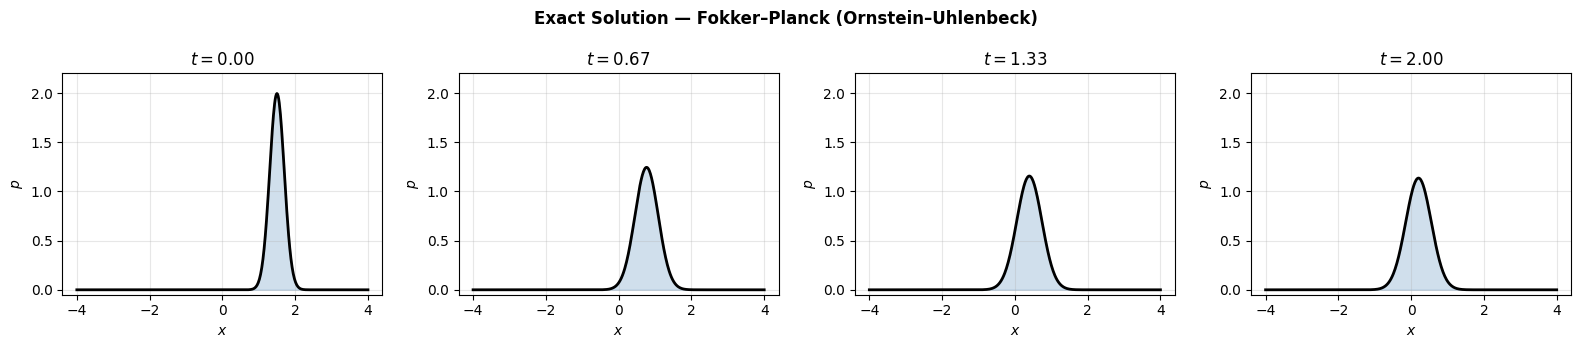

θ = 1.0,  σ = 0.5,  D = σ²/2 = 0.125
Stationary distribution: N(0, 0.125),  std = 0.354
At t=2.0: mean = 0.2030, var = 0.1234, std = 0.3513


In [ ]:
def mean_t(t):
    """OU mean at time t."""
    return M0 * np.exp(-THETA * t)


def var_t(t):
    """OU variance at time t."""
    return V0 * np.exp(-2 * THETA * t) + (SIGMA**2 / (2 * THETA)) * (1 - np.exp(-2 * THETA * t))


def p_exact(x, t):
    """Exact Gaussian solution of the Fokker–Planck equation."""
    m = mean_t(t)
    v = var_t(t)
    return (1 / np.sqrt(2 * np.pi * v)) * np.exp(-(x - m)**2 / (2 * v))


def p_init(x):
    """Initial condition p(x, 0)."""
    return p_exact(x, 0.0)


# Quick preview — exact solution at several times
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
x_plot = np.linspace(-L, L, 500)
for ax, t_snap in zip(axes, [0.0, 0.67, 1.33, 2.0]):
    ax.plot(x_plot, p_exact(x_plot, t_snap), "k-", lw=2)
    ax.fill_between(x_plot, p_exact(x_plot, t_snap), alpha=0.25, color="steelblue")
    ax.set_title(f"$t = {t_snap:.2f}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$p$")
    ax.set_ylim(-0.05, 2.2)
    ax.grid(alpha=0.3)

plt.suptitle("Exact Solution — Fokker–Planck (Ornstein–Uhlenbeck)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"θ = {THETA},  σ = {SIGMA},  D = σ²/2 = {D_COEFF}")
print(f"Stationary distribution: N(0, {SIGMA**2 / (2 * THETA):.3f}),  std = {np.sqrt(SIGMA**2 / (2 * THETA)):.3f}")
print(f"At t={T_END}: mean = {mean_t(T_END):.4f}, var = {var_t(T_END):.4f}, std = {np.sqrt(var_t(T_END)):.4f}")

---

## Part 1 — Numerical Methods

We solve the Fokker–Planck equation **forward in time** from $t = 0$ to $t = T$.

### 1-A. FTCS — Forward Time, Central Space (Explicit)

Using the expanded form $p_t = \theta p + \theta x\,p_x + D\,p_{xx}$ with central differences:

$$p_j^{n+1} = p_j^n + \Delta t\left[\theta\,p_j^n + \theta\,x_j\,\frac{p_{j+1}^n - p_{j-1}^n}{2\,\Delta x} + D\,\frac{p_{j+1}^n - 2p_j^n + p_{j-1}^n}{\Delta x^2}\right]$$

**Stability requirements**:
- Diffusion: $s = D\,\Delta t\,/\,\Delta x^2 \leq \tfrac{1}{2}$
- Advection: the variable velocity $\theta x_j$ must satisfy a local CFL condition

In [5]:
def solve_ftcs(Nx=200, Nt=400, T=T_END):
    """
    FTCS (explicit) for the Fokker–Planck equation.

    Parameters
    ----------
    Nx : int   Interior grid points.
    Nt : int   Number of time steps.

    Returns
    -------
    x      : ndarray (Nx+2,)   Grid including boundary points.
    p_hist : list of ndarray   Solution snapshots.
    t_hist : list of float     Snapshot times.
    """
    x   = np.linspace(-L, L, Nx + 2)
    dx  = x[1] - x[0]
    dt  = T / Nt

    s  = D_COEFF * dt / dx**2
    rmax = THETA * L * dt / (2 * dx)

    # Stability check
    assert s <= 0.5, f"Diffusion CFL violated: s = {s:.4f} > 0.5"
    print(f"FTCS — dx={dx:.4f}, dt={dt:.6f}, s={s:.4f}, max|r_j|={rmax:.4f}")

    p       = p_init(x).copy()
    p[0]    = p[-1] = 0.0

    snap_steps = [0, Nt // 3, 2 * Nt // 3, Nt]
    p_hist, t_hist = [], []

    for n in range(Nt + 1):
        if n in snap_steps:
            p_hist.append(p.copy())
            t_hist.append(n * dt)
        if n == Nt:
            break

        p_new       = p.copy()
        p_new[1:-1] = (p[1:-1]
                       + dt * THETA * p[1:-1]
                       + dt * THETA * x[1:-1] * (p[2:] - p[:-2]) / (2 * dx)
                       + dt * D_COEFF * (p[2:] - 2 * p[1:-1] + p[:-2]) / dx**2)
        p_new[0]    = 0.0
        p_new[-1]   = 0.0
        p           = p_new

    return x, p_hist, t_hist


Nx_ftcs, Nt_ftcs                    = 200, 5000
x_ftcs, p_ftcs_hist, t_ftcs_hist    = solve_ftcs(Nx_ftcs, Nt_ftcs)

# Error at final time
p_ex_ftcs   = p_exact(x_ftcs, T_END)
err_ftcs    = np.abs(p_ftcs_hist[-1] - p_ex_ftcs)
print(f"Max absolute error  : {err_ftcs.max():.3e}")
print(f"Mean absolute error : {err_ftcs.mean():.3e}")

FTCS — dx=0.0398, dt=0.000400, s=0.0316, max|r_j|=0.0201
Max absolute error  : 3.063e-03
Mean absolute error : 3.457e-04


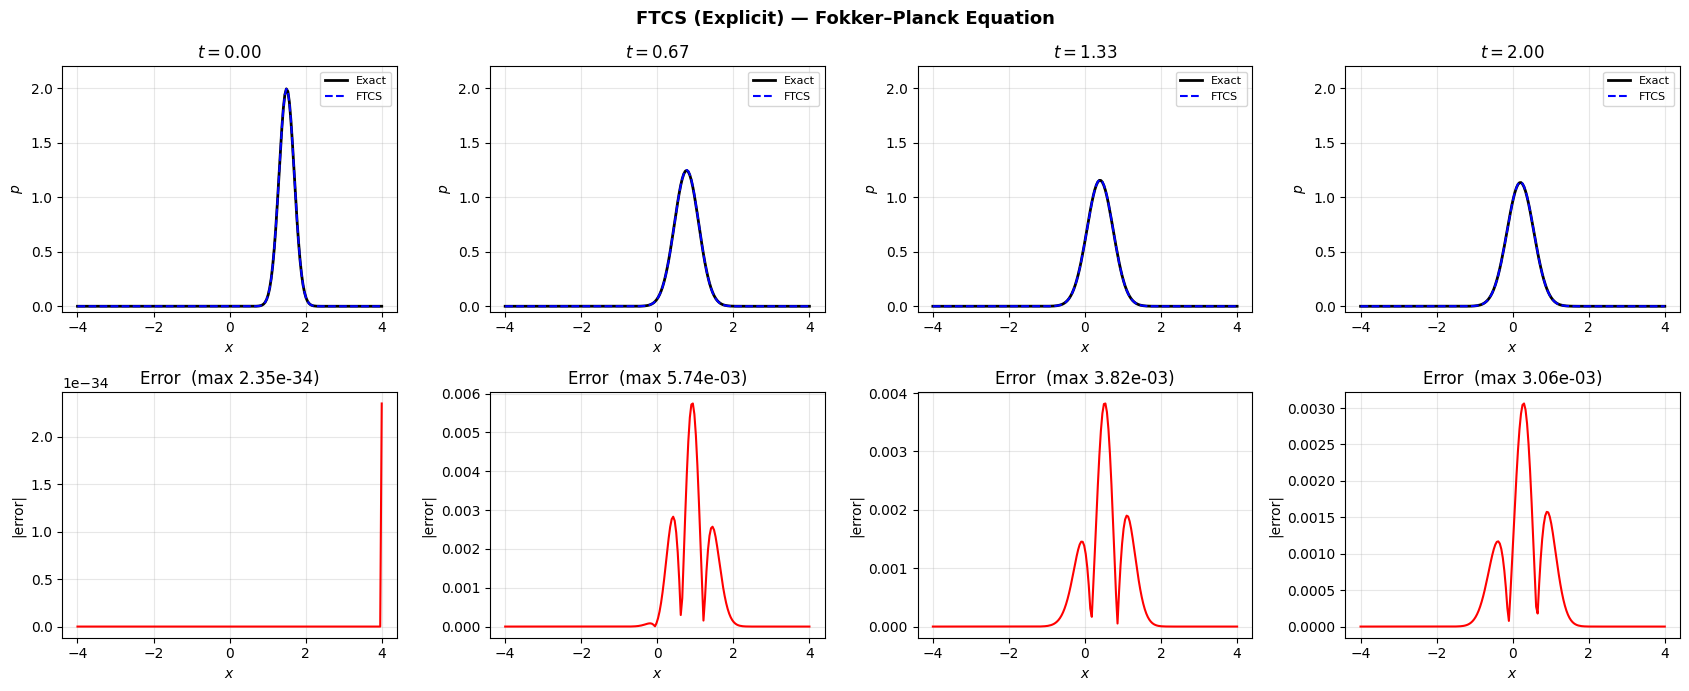

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (p_snap, t_snap) in enumerate(zip(p_ftcs_hist, t_ftcs_hist)):
    p_ref = p_exact(x_ftcs, t_snap)

    axes[0, col].plot(x_ftcs, p_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_ftcs, p_snap, "b--", lw=1.5, label="FTCS")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$p$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 2.2)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(p_snap - p_ref)
    axes[1, col].plot(x_ftcs, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("FTCS (Explicit) — Fokker–Planck Equation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1-B. Crank–Nicolson (Implicit)

The Crank–Nicolson scheme averages the spatial operator at levels $n$ and $n+1$:

$$\left(I - \frac{\Delta t}{2}\mathcal{L}\right)\mathbf{p}^{n+1} = \left(I + \frac{\Delta t}{2}\mathcal{L}\right)\mathbf{p}^n$$

where the spatial operator (expanded form) is:

$$\mathcal{L}p_j = \theta\,p_j + \theta\,x_j\,\frac{p_{j+1} - p_{j-1}}{2\,\Delta x} + D\,\frac{p_{j+1} - 2p_j + p_{j-1}}{\Delta x^2}$$

The tridiagonal coefficients of $\mathcal{L}$ at each grid point $j$ are:

| Role | Coefficient |
|------|------------|
| $p_{j-1}$ (sub) | $a_j = D/\Delta x^2 - \theta x_j/(2\Delta x)$ |
| $p_j$ (diag) | $b = \theta - 2D/\Delta x^2$ |
| $p_{j+1}$ (super) | $c_j = D/\Delta x^2 + \theta x_j/(2\Delta x)$ |

Note $b$ is constant but $a_j$ and $c_j$ vary with $x_j$ (variable advection). The resulting tridiagonal system $A\,\mathbf{p}^{n+1} = B\,\mathbf{p}^n$ has:

| Band | $A$ (LHS) | $B$ (RHS) |
|------|-----------|----------|
| sub-diagonal | $-(\Delta t/2)\,a_j$ | $(\Delta t/2)\,a_j$ |
| diagonal | $1 - (\Delta t/2)\,b$ | $1 + (\Delta t/2)\,b$ |
| super-diagonal | $-(\Delta t/2)\,c_j$ | $(\Delta t/2)\,c_j$ |

Crank–Nicolson is **unconditionally stable** and $\mathcal{O}(\Delta t^2,\,\Delta x^2)$.

In [7]:
def solve_crank_nicolson(Nx=200, Nt=200, T=T_END):
    """
    Crank–Nicolson for the Fokker–Planck equation.

    Parameters
    ----------
    Nx : int   Interior grid points.
    Nt : int   Number of time steps.

    Returns
    -------
    x      : ndarray (Nx+2,)
    p_hist : list of ndarray
    t_hist : list of float
    """
    x   = np.linspace(-L, L, Nx + 2)
    dx  = x[1] - x[0]
    dt  = T / Nt

    x_int = x[1:-1]    # N interior points
    N     = len(x_int)

    # Tridiagonal coefficients of L at each interior point
    a = D_COEFF / dx**2 - THETA * x_int / (2 * dx)   # sub-diagonal  (N,)
    b = THETA - 2 * D_COEFF / dx**2                   # diagonal      (scalar)
    c = D_COEFF / dx**2 + THETA * x_int / (2 * dx)    # super-diagonal (N,)

    print(f"Crank–Nicolson — dx={dx:.4f}, dt={dt:.5f}, N_int={N}")

    # Build LHS banded matrix: A = I − (dt/2)·L
    A_band          = np.zeros((3, N))
    A_band[0, 1:]   = -(dt / 2) * c[:-1]       # super-diagonal
    A_band[1, :]    = 1 - (dt / 2) * b          # diagonal
    A_band[2, :-1]  = -(dt / 2) * a[1:]         # sub-diagonal

    # RHS multiply: B = I + (dt/2)·L
    def rhs_multiply(p_int):
        r       = (1 + (dt / 2) * b) * p_int.copy()
        r[:-1]  += (dt / 2) * c[:-1] * p_int[1:]     # super-diagonal
        r[1:]   += (dt / 2) * a[1:]  * p_int[:-1]    # sub-diagonal
        return r

    p       = p_init(x).copy()
    p[0]    = p[-1] = 0.0

    snap_steps = [0, Nt // 3, 2 * Nt // 3, Nt]
    p_hist, t_hist = [], []

    for n in range(Nt + 1):
        if n in snap_steps:
            p_hist.append(p.copy())
            t_hist.append(n * dt)
        if n == Nt:
            break

        rhs     = rhs_multiply(p[1:-1])
        p[1:-1] = solve_banded((1, 1), A_band, rhs)
        p[0]    = 0.0
        p[-1]   = 0.0

    return x, p_hist, t_hist


Nx_cn, Nt_cn = 200, 200
x_cn, p_cn_hist, t_cn_hist = solve_crank_nicolson(Nx_cn, Nt_cn)

p_ex_cn = p_exact(x_cn, T_END)
err_cn  = np.abs(p_cn_hist[-1] - p_ex_cn)
print(f"Max absolute error  : {err_cn.max():.3e}")
print(f"Mean absolute error : {err_cn.mean():.3e}")

Crank–Nicolson — dx=0.0398, dt=0.01000, N_int=200
Max absolute error  : 3.026e-03
Mean absolute error : 3.386e-04


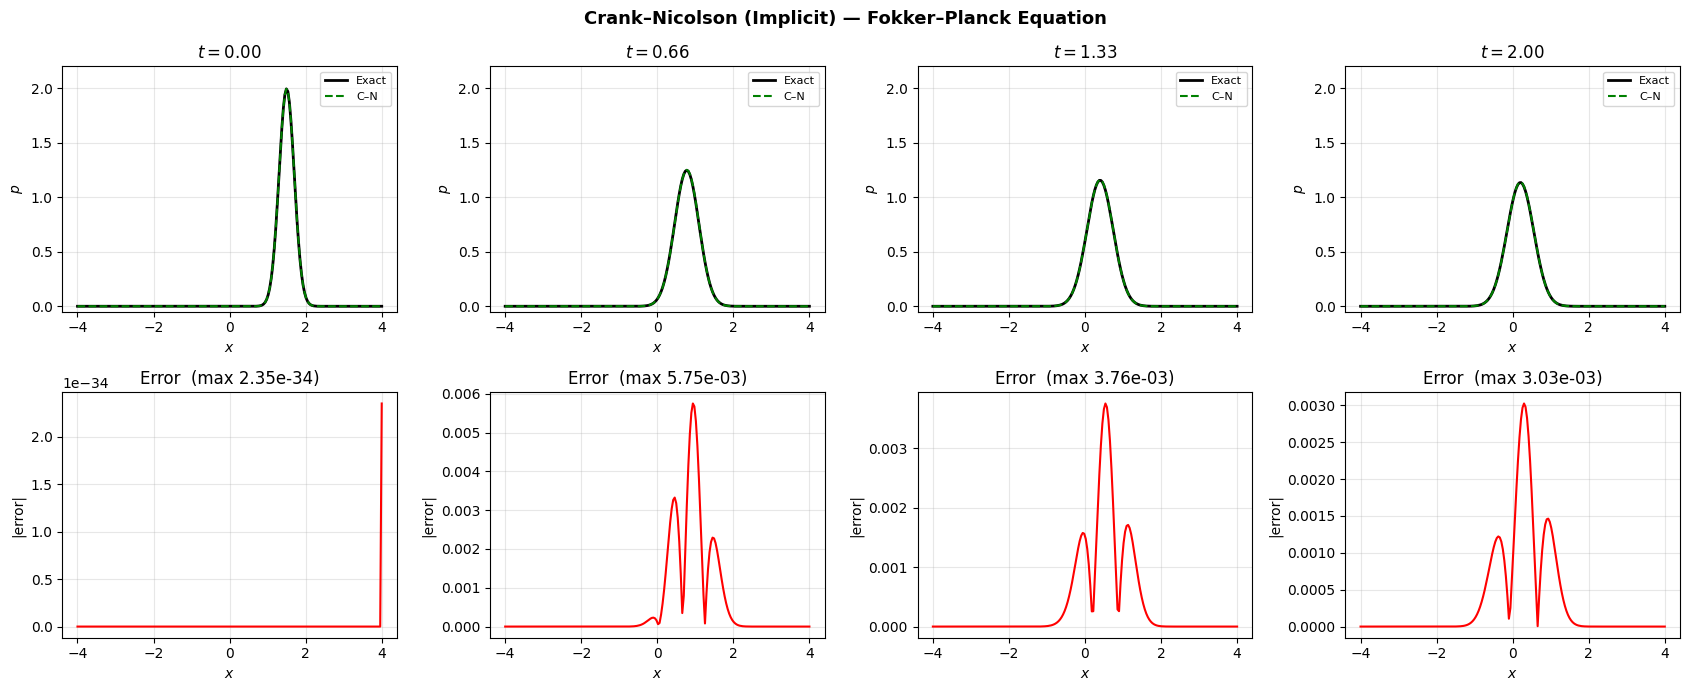

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (p_snap, t_snap) in enumerate(zip(p_cn_hist, t_cn_hist)):
    p_ref = p_exact(x_cn, t_snap)

    axes[0, col].plot(x_cn, p_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_cn, p_snap, "g--", lw=1.5, label="C–N")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$p$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 2.2)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(p_snap - p_ref)
    axes[1, col].plot(x_cn, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Crank–Nicolson (Implicit) — Fokker–Planck Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

FTCS — dx=0.3077, dt=0.005000, s=0.0066, max|r_j|=0.0325
Crank–Nicolson — dx=0.3077, dt=0.00500, N_int=25
FTCS — dx=0.1569, dt=0.005000, s=0.0254, max|r_j|=0.0638
Crank–Nicolson — dx=0.1569, dt=0.00500, N_int=50
FTCS — dx=0.0792, dt=0.005000, s=0.0996, max|r_j|=0.1262
Crank–Nicolson — dx=0.0792, dt=0.00500, N_int=100
FTCS — dx=0.0398, dt=0.005000, s=0.3945, max|r_j|=0.2513
Crank–Nicolson — dx=0.0398, dt=0.00500, N_int=200
FTCS — dx=0.0200, dt=0.001273, s=0.3998, max|r_j|=0.1276
Crank–Nicolson — dx=0.0200, dt=0.00500, N_int=400


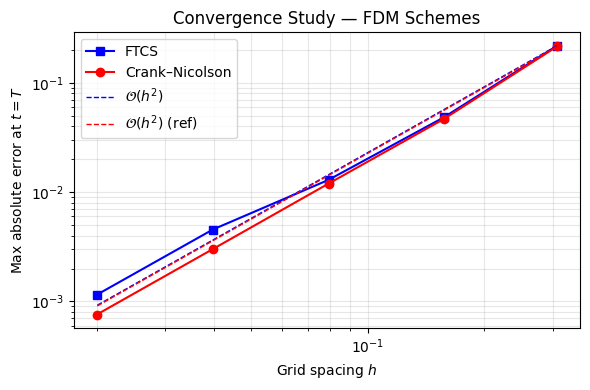

In [9]:
# ---- Grid-refinement convergence study ----------------------------------------
Nx_list = [25, 50, 100, 200, 400]
err_ftcs_conv, err_cn_conv = [], []

for Nx in Nx_list:
    # FTCS needs enough time steps for stability
    dx_c = 2 * L / (Nx + 1)
    Nt_c = max(int(np.ceil(T_END * D_COEFF / (0.4 * dx_c**2))), 400)
    x_c, p_c, t_c   = solve_ftcs(Nx, Nt_c)
    p_ex_c           = p_exact(x_c, t_c[-1])
    err_ftcs_conv.append(np.max(np.abs(p_c[-1] - p_ex_c)))

    # Crank–Nicolson — fixed moderate Nt
    x_c2, p_c2, t_c2 = solve_crank_nicolson(Nx, Nt=400)
    p_ex_c2           = p_exact(x_c2, t_c2[-1])
    err_cn_conv.append(np.max(np.abs(p_c2[-1] - p_ex_c2)))

dh = [2 * L / (Nx + 1) for Nx in Nx_list]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dh, err_ftcs_conv, "bs-", lw=1.5, label="FTCS")
ax.loglog(dh, err_cn_conv,   "ro-", lw=1.5, label="Crank–Nicolson")
ax.loglog(dh, [h**2 * err_ftcs_conv[0] / dh[0]**2 for h in dh], "b--", lw=1.0, label="$\\mathcal{O}(h^2)$")
ax.loglog(dh, [h**2 * err_cn_conv[0] / dh[0]**2 for h in dh], "r--", lw=1.0, label="$\\mathcal{O}(h^2)$ (ref)")
ax.set_xlabel("Grid spacing $h$")
ax.set_ylabel("Max absolute error at $t = T$")
ax.set_title("Convergence Study — FDM Schemes")
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### How It Works

A PINN learns $\hat{p}_\theta(x, t)$ by minimising:

$$\mathcal{L} = \underbrace{\mathcal{L}_{IC}}_{\text{initial condition}} + \underbrace{\mathcal{L}_{BC}}_{\text{boundary}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics residual}}$$

$$\mathcal{L}_{IC} = \frac{1}{N_{IC}}\sum_k \Bigl(\hat{p}(x_k, 0) - p_0(x_k)\Bigr)^2$$

$$\mathcal{L}_{BC} = \frac{1}{N_{BC}}\sum_k \left[\hat{p}(-L, t_k)^2 + \hat{p}(L, t_k)^2\right]$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_k \left(\frac{\partial\hat{p}}{\partial t} - \theta\,\hat{p} - \theta\,x_k\,\frac{\partial\hat{p}}{\partial x} - D\,\frac{\partial^2\hat{p}}{\partial x^2}\right)^2$$

The **variable-coefficient** advection term $\theta x\,p_x$ is handled seamlessly by automatic differentiation. The second derivative $p_{xx}$ is obtained via two successive calls to `torch.autograd.grad`.

**Sampling strategy** — the density starts as a narrow peak at $x_0 = 1.5$ and drifts toward $x = 0$ while broadening. We therefore combine:
- **Uniform** IC samples over the full domain
- **Focused** IC points near the initial Gaussian peak

Training: **Adam** warm-up → **L-BFGS** fine-tuning.

In [10]:
# -----------------------------------------------------------------
# Network Architecture
# -----------------------------------------------------------------
class FokkerPlanckPINN(nn.Module):
    """Fully-connected PINN: (x, t) → p.
    Tanh activations ensure smooth second-order derivatives via autograd.
    """

    def __init__(self, hidden_layers=5, hidden_dim=80):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def grad1(u, v):
    return torch.autograd.grad(
        u, v, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]


# -----------------------------------------------------------------
# Collocation / IC / BC Points
# -----------------------------------------------------------------
N_IC_UNIF   = 2000    # uniform IC points
N_IC_FOCUS  = 1500    # focused near initial Gaussian peak
N_BC        = 1000    # boundary points (each side)
N_INT       = 10000   # interior PDE collocation points

# ---- Uniform IC at t = 0 --------------------------
x_ic_u = (torch.rand(N_IC_UNIF, 1) * 2 * L - L)
t_ic_u = torch.zeros(N_IC_UNIF, 1)
p_ic_u = torch.tensor(
    p_init(x_ic_u.numpy()), dtype=torch.float32
)

# ---- Focused IC near Gaussian peak (x0 = 1.5) ----
x_ic_f = torch.randn(N_IC_FOCUS, 1) * np.sqrt(V0) + M0
x_ic_f = x_ic_f.clamp(-L, L)
t_ic_f = torch.zeros(N_IC_FOCUS, 1)
p_ic_f = torch.tensor(
    p_init(x_ic_f.numpy()), dtype=torch.float32
)

# ---- Merge IC sets --------------------------------
x_ic = torch.cat([x_ic_u, x_ic_f])
t_ic = torch.cat([t_ic_u, t_ic_f])
p_ic = torch.cat([p_ic_u, p_ic_f])

# ---- Boundary points (x = ±L) --------------------
t_bc = torch.rand(N_BC, 1) * T_END
x_bc_left  = torch.full((N_BC, 1), -L)
x_bc_right = torch.full((N_BC, 1),  L)

# ---- Interior PDE collocation points --------------
x_int = (torch.rand(N_INT, 1) * 2 * L - L).requires_grad_(True)
t_int = (torch.rand(N_INT, 1) * T_END).requires_grad_(True)

mse = nn.MSELoss()

print(f"IC  points : {len(x_ic)}")
print(f"BC  points : {2 * N_BC}")
print(f"PDE points : {N_INT}")

IC  points : 3500
BC  points : 2000
PDE points : 10000


In [11]:
def compute_loss(model):
    # ---- Initial-condition loss ------
    p_pred_ic   = model(x_ic, t_ic)
    loss_ic     = mse(p_pred_ic, p_ic)

    # ---- Boundary loss (p = 0 at x = ±L) -----
    p_left  = model(x_bc_left,  t_bc)
    p_right = model(x_bc_right, t_bc)
    loss_bc = mse(p_left,  torch.zeros_like(p_left)) + mse(p_right, torch.zeros_like(p_right))

    # ---- PDE residual: p_t − θp − θx·p_x − D·p_xx = 0 -----
    p_pred  = model(x_int, t_int)
    p_t     = grad1(p_pred, t_int)
    p_x     = grad1(p_pred, x_int)
    p_xx    = grad1(p_x,    x_int)
    residual = p_t - THETA * p_pred - THETA * x_int * p_x - D_COEFF * p_xx
    loss_pde = mse(residual, torch.zeros_like(residual))

    return loss_ic + loss_bc + loss_pde, loss_ic, loss_bc, loss_pde


# ---- Phase 1: Adam --------------------------------
model = FokkerPlanckPINN(hidden_layers=5, hidden_dim=80)
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
ADAM_EP = 5000
history = []

for ep in range(1, ADAM_EP + 1):
    opt_adam.zero_grad()
    loss, l_ic, l_bc, l_pde = compute_loss(model)
    loss.backward()
    opt_adam.step()
    history.append(loss.item())
    if ep % 1000 == 0:
        print(f"[Adam] Ep {ep:5d} | Loss {loss.item():.5f} | "
              f"IC {l_ic.item():.5f} | BC {l_bc.item():.5f} | PDE {l_pde.item():.5f}")

print("Adam phase done.")

[Adam] Ep  1000 | Loss 0.00020 | IC 0.00006 | BC 0.00000 | PDE 0.00014
[Adam] Ep  2000 | Loss 0.00005 | IC 0.00001 | BC 0.00000 | PDE 0.00004
[Adam] Ep  3000 | Loss 0.00042 | IC 0.00023 | BC 0.00011 | PDE 0.00008
[Adam] Ep  4000 | Loss 0.00001 | IC 0.00000 | BC 0.00000 | PDE 0.00001
[Adam] Ep  5000 | Loss 0.00001 | IC 0.00000 | BC 0.00000 | PDE 0.00001
Adam phase done.


L-BFGS done.  Final loss: 0.000001


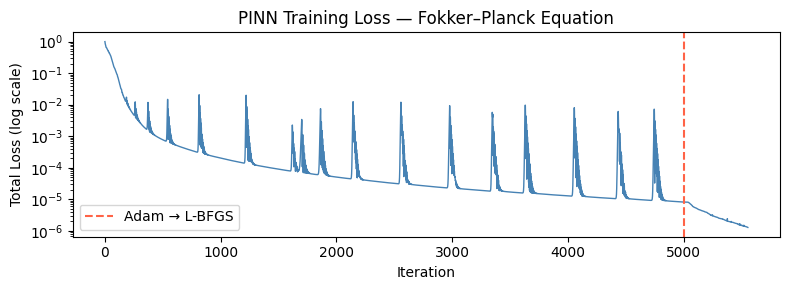

In [12]:
# ---- Phase 2: L-BFGS ----
opt_lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12,
    history_size=50, line_search_fn="strong_wolfe"
)


def closure():
    opt_lbfgs.zero_grad()
    loss, _, _, _ = compute_loss(model)
    loss.backward()
    history.append(loss.item())
    return loss


opt_lbfgs.step(closure)
final, _, _, _ = compute_loss(model)
print(f"L-BFGS done.  Final loss: {final.item():.6f}")

# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history, color="steelblue", lw=1.0)
ax.axvline(x=ADAM_EP, color="tomato", ls="--", lw=1.5, label="Adam → L-BFGS")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total Loss (log scale)")
ax.set_title("PINN Training Loss — Fokker–Planck Equation")
ax.legend()
plt.tight_layout()
plt.show()

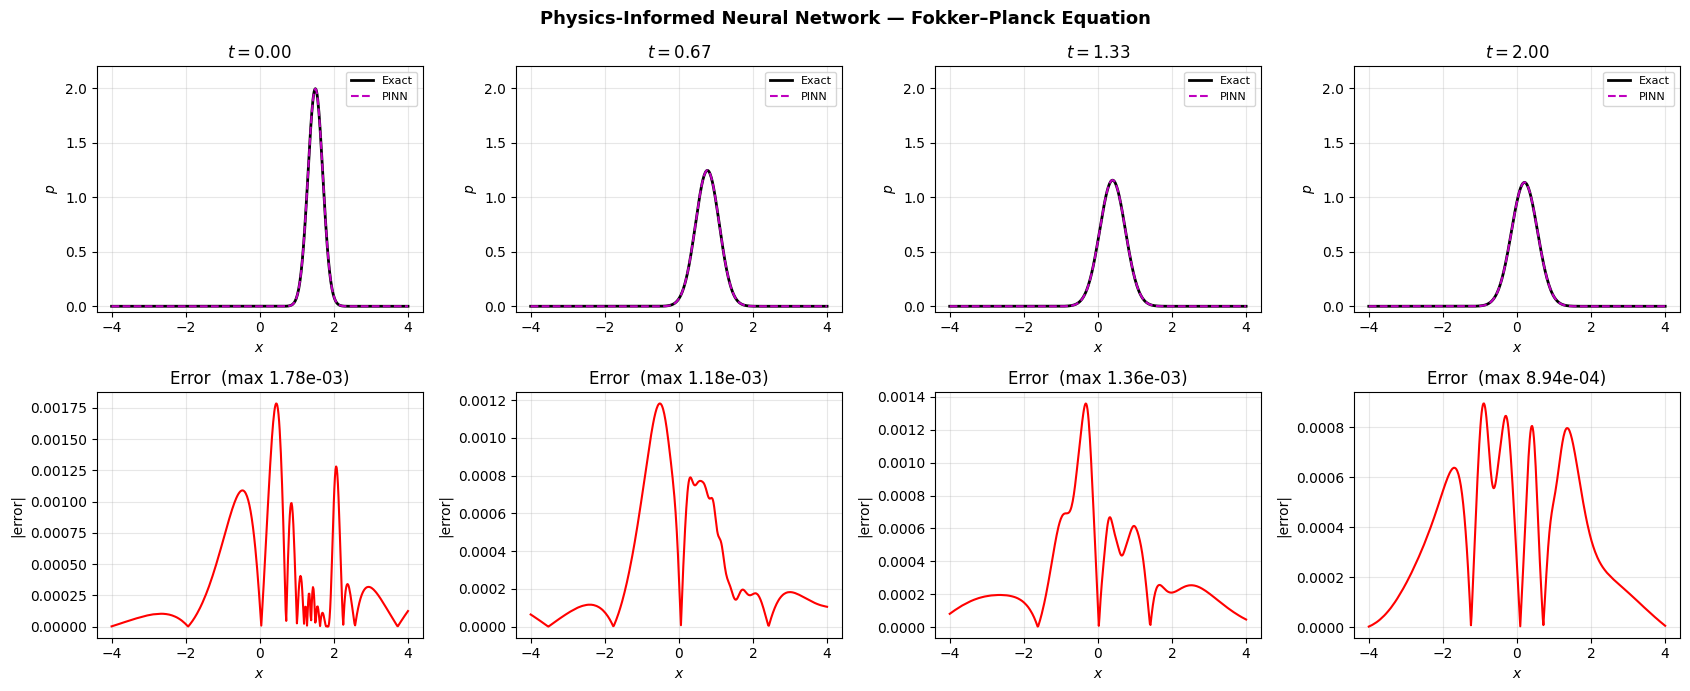

PINN — Max error at t=T: 8.94e-04  |  Mean error: 3.60e-04


In [13]:
# ---- Evaluate PINN on a dense x grid at each snapshot time ----
model.eval()
Nev  = 500
x_ev = np.linspace(-L, L, Nev)


def pinn_predict(t_val):
    xt = torch.tensor(x_ev, dtype=torch.float32).unsqueeze(1)
    tt = torch.full((Nev, 1), t_val, dtype=torch.float32)
    with torch.no_grad():
        return model(xt, tt).numpy().ravel()


snap_times_pinn = [0.0, T_END / 3, 2 * T_END / 3, T_END]
P_pinn_snaps    = [pinn_predict(t) for t in snap_times_pinn]

# PINN error at final time
P_ex_pinn   = p_exact(x_ev, T_END)
err_pinn    = np.abs(P_pinn_snaps[-1] - P_ex_pinn)

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for col, (P_snap, t_snap) in enumerate(zip(P_pinn_snaps, snap_times_pinn)):
    p_ref = p_exact(x_ev, t_snap)

    axes[0, col].plot(x_ev, p_ref, "k-", lw=2, label="Exact")
    axes[0, col].plot(x_ev, P_snap, "m--", lw=1.5, label="PINN")
    axes[0, col].set_title(f"$t = {t_snap:.2f}$")
    axes[0, col].set_xlabel("$x$")
    axes[0, col].set_ylabel("$p$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_ylim(-0.05, 2.2)
    axes[0, col].grid(alpha=0.3)

    err = np.abs(P_snap - p_ref)
    axes[1, col].plot(x_ev, err, "r-", lw=1.5)
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$x$")
    axes[1, col].set_ylabel("|error|")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Physics-Informed Neural Network — Fokker–Planck Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"PINN — Max error at t=T: {err_pinn.max():.2e}  |  Mean error: {err_pinn.mean():.2e}")

---

## Part 3 — Side-by-Side Comparison

Solutions from all three methods at $t = T$ alongside the exact solution, plus a quantitative error summary.

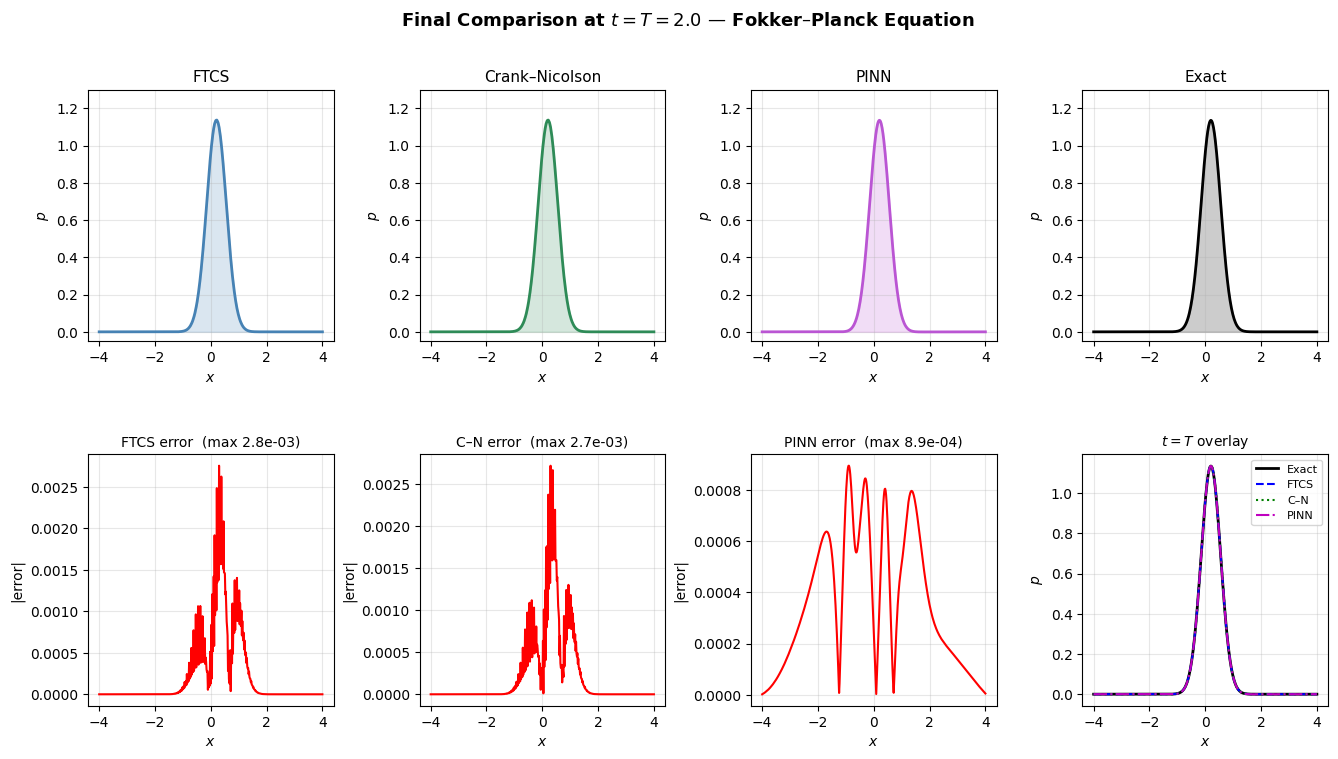

In [14]:
# Interpolate FD solutions onto the common evaluation grid
from scipy.interpolate import interp1d

p_ftcs_ev   = interp1d(x_ftcs, p_ftcs_hist[-1], kind="linear", bounds_error=False, fill_value=0.0)(x_ev)
p_cn_ev     = interp1d(x_cn,   p_cn_hist[-1],   kind="linear", bounds_error=False, fill_value=0.0)(x_ev)
p_pinn_ev   = P_pinn_snaps[-1]

err_ftcs_ev = np.abs(p_ftcs_ev - P_ex_pinn)
err_cn_ev   = np.abs(p_cn_ev   - P_ex_pinn)
err_pinn_ev = np.abs(p_pinn_ev - P_ex_pinn)

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

labels  = ["FTCS", "Crank–Nicolson", "PINN", "Exact"]
sols    = [p_ftcs_ev, p_cn_ev, p_pinn_ev, P_ex_pinn]
colors  = ["steelblue", "seagreen", "mediumorchid", "black"]
errs    = [err_ftcs_ev, err_cn_ev, err_pinn_ev]
e_lbl   = ["FTCS error", "C–N error", "PINN error"]

for col, (lbl, sol, c) in enumerate(zip(labels, sols, colors)):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(x_ev, sol, color=c, lw=2)
    ax.fill_between(x_ev, sol, alpha=0.2, color=c)
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$p$")
    ax.set_ylim(-0.05, 1.3)
    ax.grid(alpha=0.3)

for col, (lbl, err) in enumerate(zip(e_lbl, errs)):
    ax = fig.add_subplot(gs[1, col])
    ax.plot(x_ev, err, "r-", lw=1.5)
    ax.set_title(f"{lbl}  (max {err.max():.1e})", fontsize=10)
    ax.set_xlabel("$x$")
    ax.set_ylabel("|error|")
    ax.grid(alpha=0.3)

# Overlay plot for direct comparison
ax_ov = fig.add_subplot(gs[1, 3])
ax_ov.plot(x_ev, P_ex_pinn,  "k-",  lw=2,   label="Exact")
ax_ov.plot(x_ev, p_ftcs_ev,  "b--", lw=1.5, label="FTCS")
ax_ov.plot(x_ev, p_cn_ev,    "g:",  lw=1.5, label="C–N")
ax_ov.plot(x_ev, p_pinn_ev,  "m-.", lw=1.5, label="PINN")
ax_ov.set_title("$t = T$ overlay", fontsize=10)
ax_ov.set_xlabel("$x$")
ax_ov.set_ylabel("$p$")
ax_ov.legend(fontsize=8)
ax_ov.grid(alpha=0.3)

fig.suptitle(f"Final Comparison at $t = T = {T_END}$ — Fokker–Planck Equation", fontsize=13, fontweight="bold")
plt.show()

In [ ]:
# ---- Quantitative error summary + probability conservation check ----
def l2_norm(f_arr, x_arr):
      return np.sqrt(np.trapezoid(f_arr**2, x_arr))

I_exact_0  = np.trapezoid(p_exact(x_ev, 0.0),   x_ev)
I_exact_T  = np.trapezoid(P_ex_pinn,             x_ev)
I_ftcs     = np.trapezoid(p_ftcs_ev,             x_ev)
I_cn       = np.trapezoid(p_cn_ev,               x_ev)
I_pinn     = np.trapezoid(p_pinn_ev,             x_ev)

print("=" * 72)
print(f"{'Method':<22} {'Max error':>12} {'Mean error':>12} {'L² error':>12} {'∫p dx':>10}")
print("-" * 72)
print(f"{'Exact (t=0)':22} {'—':>12} {'—':>12} {'—':>12} {I_exact_0:>10.4f}")
print(f"{'Exact (t=T)':22} {'—':>12} {'—':>12} {'—':>12} {I_exact_T:>10.4f}")
print(f"{'FTCS':22} {err_ftcs_ev.max():>12.3e} {err_ftcs_ev.mean():>12.3e} "
      f"{l2_norm(err_ftcs_ev, x_ev):>12.3e} {I_ftcs:>10.4f}")
print(f"{'Crank–Nicolson':22} {err_cn_ev.max():>12.3e} {err_cn_ev.mean():>12.3e} "
      f"{l2_norm(err_cn_ev, x_ev):>12.3e} {I_cn:>10.4f}")
print(f"{'PINN':22} {err_pinn_ev.max():>12.3e} {err_pinn_ev.mean():>12.3e} "
      f"{l2_norm(err_pinn_ev, x_ev):>12.3e} {I_pinn:>10.4f}")
print("=" * 72)
print(f"\nNote: ∫p dx should be conserved (= 1) for all methods (probability conservation).")

Method                    Max error   Mean error     L² error      ∫p dx
------------------------------------------------------------------------
Exact (t=0)                       —            —            —     1.0000
Exact (t=T)                       —            —            —     1.0000
FTCS                      2.755e-03    2.245e-04    1.450e-03     1.0000
Crank–Nicolson            2.717e-03    2.230e-04    1.436e-03     1.0000
PINN                      8.945e-04    3.602e-04    1.258e-03     0.9993

Note: ∫p dx should be conserved (= 1) for all methods (probability conservation).


---

## Summary

### About the Fokker–Planck Equation

The Fokker–Planck equation (also known as Kolmogorov's forward equation) is a cornerstone of stochastic dynamics, statistical physics, and mathematical finance. Key properties:

- It is a **linear, second-order parabolic PDE** with a variable drift coefficient $\theta x$ determined by the underlying stochastic process. It describes the forward-time evolution of the probability density.
- For the **Ornstein–Uhlenbeck process**, the solution is always Gaussian — the mean decays exponentially toward zero and the variance relaxes toward the equilibrium value $\sigma^2/(2\theta)$.
- **Probability conservation**: $\int p\,dx = 1$ for all $t$ (the divergence-form structure guarantees this). This provides a strong numerical check.
- The **stationary distribution** $p_\infty(x) \propto \exp(-\theta x^2/\sigma^2)$ satisfies detailed balance and is the Boltzmann distribution for the quadratic potential $U(x) = \theta x^2/2$.

### Method Comparison

| Aspect | FTCS (Explicit) | Crank–Nicolson (Implicit) | PINN |
|--------|----------------|--------------------------|------|
| **Core idea** | Forward Euler + central differences | Trapezoidal rule + central differences | Minimise PDE + IC + BC residuals |
| **Accuracy** | $\mathcal{O}(\Delta t,\,h^2)$ | $\mathcal{O}(\Delta t^2,\,h^2)$ | Depends on training |
| **Stability** | Conditional ($s \leq 1/2$) | Unconditional | Unconditional |
| **Variable coeff.** | Straightforward (explicit update) | x-dependent tridiagonal system | Handled by autograd |
| **Probability conserv.** | Approximate | Good (second-order) | Soft (through loss) |
| **Mesh required** | Yes — uniform 1D grid | Yes — uniform 1D grid | No — meshfree |
| **Best for** | Quick prototyping | Production-grade 1D parabolic PDEs | High-dimensional or parametric problems |

### Key Observations

- **FTCS** is the simplest scheme but requires very small time steps for stability ($s \leq 1/2$), especially on fine grids where $\Delta x$ is small. It is first-order in time.
- **Crank–Nicolson** is unconditionally stable and second-order in both space and time. The variable-coefficient advection $\theta x$ makes the tridiagonal system **x-dependent** (unlike constant-coefficient problems), but the solve cost remains $\mathcal{O}(N)$ per step.
- The **PINN** is mesh-free and handles the variable-coefficient structure naturally through automatic differentiation. The narrow initial Gaussian (high peak, small variance) is challenging — focused sampling near the peak is critical for accurate IC enforcement.